<a href="https://colab.research.google.com/github/waelydz/ASD-Sense/blob/main/Model_EfficientNetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment Setup & Data Download

In [1]:
!pip install kagglehub scikit-learn -q

import os
import kagglehub
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

dataset_path = kagglehub.dataset_download('imranliaqat32/autism-spectrum-disorder-in-childrenhandgestures')

DATA_DIR = None
for root, dirs, files in os.walk(dataset_path):
    if 'ASD' in dirs and 'Non-ASD' in dirs:
        DATA_DIR = root
        break

if not DATA_DIR:
    raise FileNotFoundError("Target class directories 'ASD' and 'Non-ASD' not found.")

100%|██████████| 4.17G/4.17G [04:10<00:00, 17.8MB/s]

Extracting files...


Data Preprocessing & Class Weights

In [2]:
data = []

for category_folder in os.listdir(DATA_DIR):
    category_path = os.path.join(DATA_DIR, category_folder)
    if not os.path.isdir(category_path):
        continue

    label = 'no' if category_folder == 'Non-ASD' else 'yes'


    for root_dir, _, files in os.walk(category_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                data.append({'filepath': os.path.join(root_dir, file), 'label': label})

df = pd.DataFrame(data)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])


weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights_dict = {0: weights[0], 1: weights[1]}

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=True
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

Found 1391 validated image filenames belonging to 2 classes.
Found 348 validated image filenames belonging to 2 classes.


Initial Training (Frozen Backbone)

In [3]:
print("Building Model with Frozen EfficientNetB0 Backbone...")
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Starting Initial Training (5 Epochs)...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights_dict
)

Building Model with Frozen EfficientNetB0 Backbone...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Starting Initial Training (5 Epochs)...
Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 234s 5s/step - accuracy: 0.8900 - loss: 0.2878 - val_accuracy: 0.8822 - val_loss: 0.2700
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.9475 - loss: 0.1446 - val_accuracy: 0.9138 - val_loss: 0.2056
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.9648 - loss: 0.0930 - val_accuracy: 0.9425 - val_loss: 0.1559
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.9720 - loss: 0.0813 - val_accuracy: 0.9684 - val_loss: 0.1098
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.9705 - loss: 0.0773 - val_accuracy: 0.9713 - val_loss: 0.1023


Fine-Tuning

In [4]:
print("\nUnfreezing Top Layers for Fine-Tuning...")
base_model.trainable = True

# Unfreeze only the top 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Starting Fine-Tuning (15 Epochs)...")
fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights_dict
)

final_val_acc = fine_tune_history.history['val_accuracy'][-1] * 100
print(f"\nEfficientNetB0 Final Validation Accuracy: {final_val_acc:.2f}%")


Unfreezing Top Layers for Fine-Tuning...
Starting Fine-Tuning (15 Epochs)...
Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.9051 - loss: 0.2691 - val_accuracy: 0.9741 - val_loss: 0.0950
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.9274 - loss: 0.1902 - val_accuracy: 0.9684 - val_loss: 0.0904
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.9339 - loss: 0.1616 - val_accuracy: 0.9684 - val_loss: 0.0911
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.9461 - loss: 0.1320 - val_accuracy: 0.9684 - val_loss: 0.0926
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.9561 - loss: 0.1094 - val_accuracy: 0.9655 - val_loss: 0.0939
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.9619 - loss: 0.1086 - val_accuracy: 0.9655 - val_loss: 0.0965
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.9669 - loss: 0.1029 - val_accuracy: 0.9684 - val_loss: 0.0973
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━

Plotting

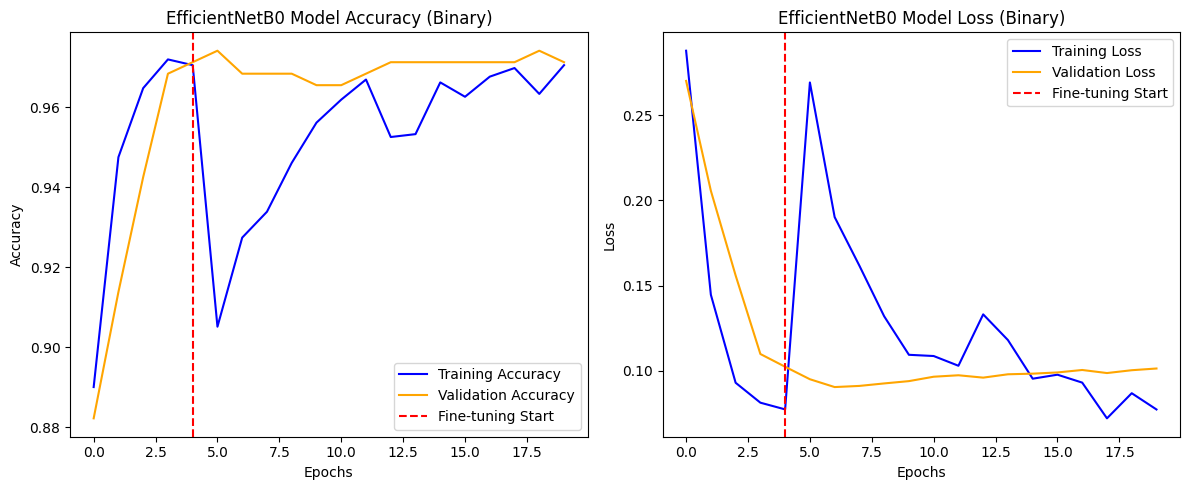

In [5]:
import matplotlib.pyplot as plt

def plot_results(hist1, hist2):
    acc = hist1.history['accuracy'] + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy', color='blue')
    plt.plot(val_acc, label='Validation Accuracy', color='orange')
    plt.axvline(x=len(hist1.history['accuracy'])-1, color='r', linestyle='--', label='Fine-tuning Start')
    plt.title('EfficientNetB0 Model Accuracy (Binary)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss', color='blue')
    plt.plot(val_loss, label='Validation Loss', color='orange')
    plt.axvline(x=len(hist1.history['loss'])-1, color='r', linestyle='--', label='Fine-tuning Start')
    plt.title('EfficientNetB0 Model Loss (Binary)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig('efficientnet_training_results.png', dpi=300)
    plt.show()

plot_results(history, fine_tune_history)